<a href="https://colab.research.google.com/github/Gguicruzz/CP2-Data-Science-/blob/main/cp02_quinteto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2ESPR - DATA SCIENCE

## Checkpoint 2

O objetivo é conduzir uma análise descritiva completa (tendência central,
dispersão, distribuição, correlação, segmentações, outliers e storytelling).

## Integrantes

- Artur Henrique Siqueira - RM566986
- Davi de Souza Malta - RM560327
- Guilherme de Oliveira Scremin - RM564788
- Guilherme cruz alves - RM566861
- Pedro Sales Ferreira - RM566990

### 1. Introdução ao Dataset

#### Como está estruturado o dataset?
O dataset possui um formato tabular com 23 linhas e 26 colunas, com unidades padronizadas (GHz, Watts, USD, mm², TFLOPS). Ele é disponibilizado em dois formatos estruturais:

CSV (amd_consumer_cpu_performance.csv): Formato de texto limpo e padronizado.

Parquet (amd_consumer_cpu_performance.parquet): Formato colunar otimizado para filtros rápidos, consultas vetorizadas e manutenção estrita da tipagem dos dados.

#### Quantos processadores (linhas) temos registrados?

Temos 23 processadores (linhas) registrados no total. Os dados cobrem mais de 30 anos de inovações de hardware, listando gerações que vão desde os antigos Am486 até as microarquiteturas mais recentes, como a Zen 5 (Ryzen 9000).

#### Quais variáveis são categóricas e quais são numéricas?

Com base na amostra do dicionário de dados fornecido, as 15 variáveis explícitas são divididas da seguinte forma:

Variáveis Categóricas e Booleanas (object / bool)

processor_name: Nome do processador

family: Família do produto (ex: Ryzen 9, EPYC)

series: Série ou nível do produto (ex: RX 7000)

codename: Codinome interno do projeto (ex: Raphael)

architecture: Microarquitetura (ex: Zen 4)

has_3d_vcache: Flag indicando presença de cache vertical (Verdadeiro/Falso)

Variáveis Numéricas (int64 / float64)

launch_year: Ano de lançamento (Discreto)

process_node_nm: Litografia de fabricação em nm (Contínuo)

transistor_count_millions: Total de transistores em milhões (Contínuo)

die_size_mm2: Área física do silício em mm² (Contínuo)

cores_total: Total de núcleos físicos (Discreto)

threads_total: Total de threads via multithreading (Discreto)

base_clock_ghz: Frequência base em GHz (Contínuo)

boost_clock_ghz: Frequência de pico em GHz (Contínuo)

l3_cache_mb: Memória cache L3 em MB (Contínuo)

In [ ]:
# ==============================
# 1) Imports, Configs e Leitura
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import kagglehub


# Baixando a versão mais recente do dataset do Kaggle
path = kagglehub.dataset_download("basselashraf/amd-consumer-cpu-performance")
print("Caminho dos arquivos do dataset:", path)

# Localizando automaticamente o arquivo CSV dentro da pasta baixada
# (Garante que vai achar o arquivo mesmo que o nome exato mude)
csv_path = list(Path(path).glob("*.csv"))[0]

# Lendo a base de dados
df = pd.read_csv(csv_path)

print("Dimensão da base:", df.shape)
df.head()

Using Colab cache for faster access to the 'amd-consumer-cpu-performance' dataset.
Caminho dos arquivos do dataset: /kaggle/input/amd-consumer-cpu-performance
Dimensão da base: (23, 26)


,processor_name,family,series,codename,architecture,launch_year,process_node_nm,transistor_count_millions,die_size_mm2,cores_total,...,ppt_watts,passmark_cpu_mark,passmark_single_thread,geekbench6_single,geekbench6_multi,cinebench_r23_multi,launch_price_usd,transistor_density_m_per_mm2,passmark_per_dollar,passmark_per_watt
0,AMD Am486DX4-100,Am486,486,Enhanced 486,486,1994,500,1.6,88.0,1,...,4.5,11.0,11.0,6.0,6.0,5.0,299,0.02,0.04,2.44
1,AMD K6-2 450,K6 Series,K6-2,Chomper,K6,1998,250,9.3,81.0,1,...,19.5,60.0,60.0,34.0,34.0,30.0,159,0.11,0.38,3.08
2,AMD Athlon 1000 (Thunderbird),Athlon,Thunderbird,Thunderbird,K7,2000,180,37.0,120.0,1,...,54.0,210.0,210.0,120.0,120.0,110.0,990,0.31,0.21,3.89
3,AMD Athlon 64 3200+,Athlon 64,ClawHammer,ClawHammer,K8,2003,130,105.9,193.0,1,...,89.0,311.0,631.0,360.0,360.0,380.0,417,0.55,0.75,3.49
4,AMD Athlon XP 2500+ (Barton),Athlon XP,Barton,Barton,K7,2003,130,54.3,101.0,1,...,68.3,231.0,353.0,200.0,200.0,205.0,172,0.54,1.34,3.38


In [ ]:

# ==============================
# 2) Visão geral e dicionário rápido
# ==============================
info = df.info()
display(df.sample(5, random_state=42))
display(df.describe(include='all').transpose())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   processor_name                23 non-null     object 
 1   family                        23 non-null     object 
 2   series                        23 non-null     object 
 3   codename                      23 non-null     object 
 4   architecture                  23 non-null     object 
 5   launch_year                   23 non-null     int64  
 6   process_node_nm               23 non-null     int64  
 7   transistor_count_millions     23 non-null     float64
 8   die_size_mm2                  23 non-null     float64
 9   cores_total                   23 non-null     int64  
 10  threads_total                 23 non-null     int64  
 11  base_clock_ghz                23 non-null     float64
 12  boost_clock_ghz               23 non-null     float64
 13  l3_cach

,processor_name,family,series,codename,architecture,launch_year,process_node_nm,transistor_count_millions,die_size_mm2,cores_total,...,ppt_watts,passmark_cpu_mark,passmark_single_thread,geekbench6_single,geekbench6_multi,cinebench_r23_multi,launch_price_usd,transistor_density_m_per_mm2,passmark_per_dollar,passmark_per_watt
15,AMD Ryzen 7 5800X,Ryzen 7,Ryzen 5000,Vermeer,Zen 3,2020,7,4150.0,80.7,8,...,142.0,28200.0,3460.0,2140.0,11800.0,15300.0,449,51.43,62.81,268.57
9,AMD FX-8350,FX Series,FX-8000,Vishera,Piledriver,2012,32,1200.0,315.0,8,...,150.0,5940.0,1520.0,710.0,3100.0,4200.0,195,3.81,30.46,47.52
0,AMD Am486DX4-100,Am486,486,Enhanced 486,486,1994,500,1.6,88.0,1,...,4.5,11.0,11.0,6.0,6.0,5.0,299,0.02,0.04,2.44
8,AMD Phenom II X6 1100T Black Edition,Phenom II,Thuban,Thuban,K10 6-Core,2010,45,904.0,346.0,6,...,145.0,3820.0,1050.0,540.0,2450.0,3350.0,265,2.61,14.42,30.56
17,AMD Ryzen 7 5800X3D (3D V-Cache),Ryzen 7,Ryzen 5000X3D,Vermeer-X,Zen 3 3D,2022,7,4150.0,121.7,8,...,142.0,28400.0,3240.0,2120.0,11750.0,14850.0,449,34.10,63.25,270.48


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
processor_name,23,23,AMD Am486DX4-100,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
family,23,12,Ryzen 7,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
series,23,21,Ryzen 5000,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
codename,23,20,Matisse,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
architecture,23,18,K8 Dual-Core,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
launch_year,23.0,NaN,NaN,NaN,2013.304348,9.329498,1994.0,2006.0,2017.0,2021.0,2024.0
process_node_nm,23.0,NaN,NaN,NaN,69.869565,114.693387,4.0,7.0,14.0,90.0,500.0
transistor_count_millions,23.0,NaN,NaN,NaN,4507.421739,5002.638065,1.6,230.3,3900.0,7400.0,16600.0
die_size_mm2,23.0,NaN,NaN,NaN,201.408696,83.170618,74.0,120.85,213.0,261.0,346.0
cores_total,23.0,NaN,NaN,NaN,7.173913,5.210585,1.0,2.0,8.0,8.0,16.0


# **# 3. Dispersão**

**Métricas: variância, desvio padrão, coeficiente de variação e quartis.**

**Perguntas adaptadas**

**O desempenho dos processadores (PassMark) apresenta grande dispersão?**

**Qual família de processadores apresenta maior consistência de desempenho?**

**Como é a variabilidade do preço de lançamento dos processadores?**

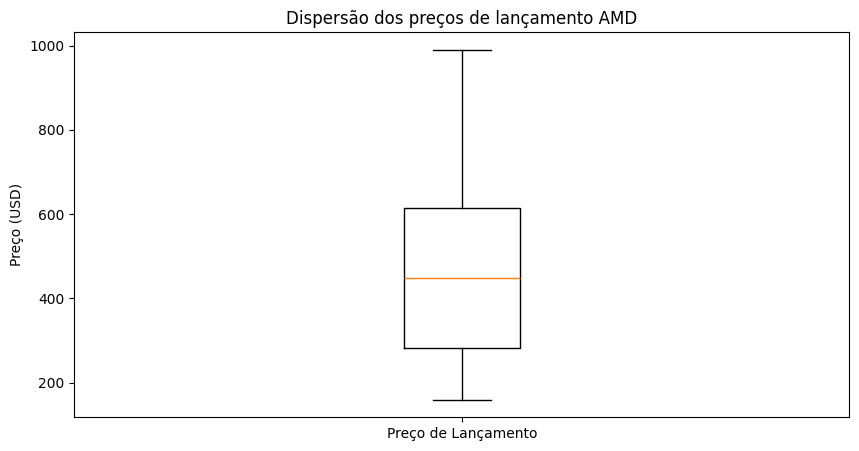

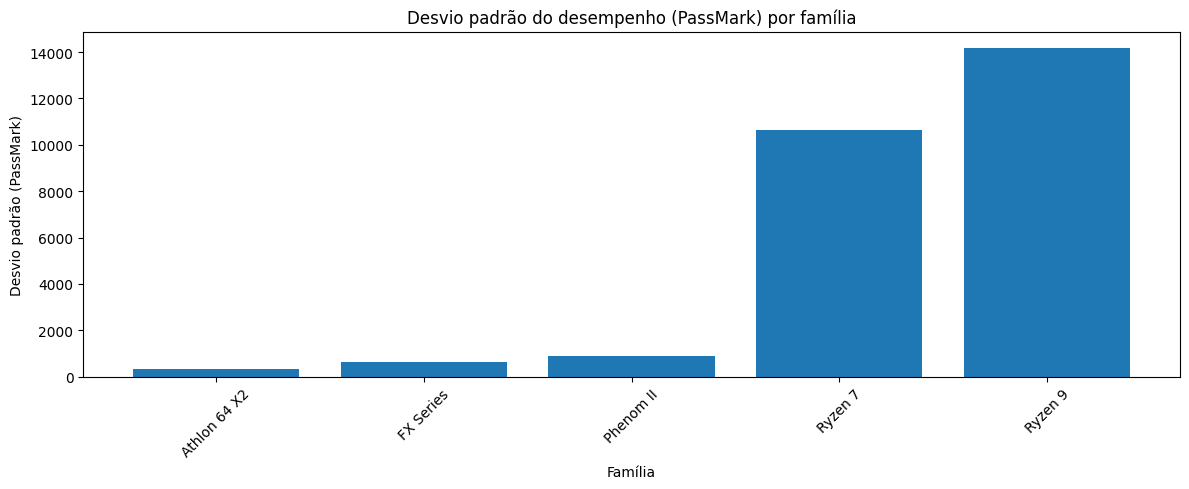

In [ ]:
# ==============================
# Gráficos
# ==============================

# Calculando a dispersão (desvio padrão) por família primeiro para corrigir o erro
dispersao = df.groupby('family')['passmark_cpu_mark'].agg(['std', 'mean', 'count'])

# 1. Gráfico de dispersão dos preços (A famosa "Bateria" / Boxplot)
plt.figure(figsize=(10, 5))
plt.boxplot(df['launch_price_usd'].dropna())
plt.title('Dispersão dos preços de lançamento AMD')
plt.ylabel('Preço (USD)')
plt.xticks([1], ['Preço de Lançamento'])
plt.show()

# >>> FORÇANDO UM ESPAÇO ENTRE OS GRÁFICOS NO COLAB <<<
print("\n" * 3)

# 2. Desvio padrão por família (Barras)
plt.figure(figsize=(12, 5))
dispersao_grafico = dispersao.dropna(subset=['std'])

plt.bar(dispersao_grafico.index, dispersao_grafico['std'])
plt.title('Desvio padrão do desempenho (PassMark) por família')
plt.xlabel('Família')
plt.ylabel('Desvio padrão (PassMark)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Respostas da questões 3:**
**1. Qual é a variabilidade do desempenho dos processadores AMD?**

*Resposta:*

O desempenho dos processadores AMD apresenta uma grande variabilidade. A média do PassMark é de aproximadamente 19.987,96 pontos, enquanto o desvio padrão é de 21.505,37 pontos. Isso demonstra que os resultados estão bastante dispersos em relação à média, indicando diferenças significativas de desempenho entre os processadores analisados.

**2. Qual família de processadores apresenta maior consistência no desempenho?**

*Resposta:*

A consistência deve ser avaliada por meio do desvio padrão e do coeficiente de variação de cada família. A família com menor dispersão relativa apresenta resultados mais homogêneos entre seus processadores. Essa comparação permite identificar quais famílias possuem desempenhos mais consistentes.

**3. Os preços dos processadores apresentam grande variação?**

*Resposta:*

Sim. Os preços apresentam uma média de aproximadamente US$ 473,30 e um desvio padrão de US$ 239,52. Isso indica uma variação considerável nos valores dos processadores, demonstrando que existem modelos com preços bastante diferentes dentro do conjunto analisado.

# 4. Distribuições

**Visualizações: histogramas, densidade, curtose e assimetria.**

**Perguntas adaptadas**

**Como se distribui o desempenho PassMark dos processadores? A distribuição é simétrica ou enviesada?**

**Existe concentração de processadores em determinadas faixas de núcleos?**

**O preço de lançamento segue uma distribuição próxima da normal?**


Variável: passmark_cpu_mark
Assimetria: 0.8410638255070261
Curtose: -0.4025855763795527

Variável: launch_price_usd
Assimetria: 0.5447504699053057
Curtose: -0.5349996829744228

Variável: cores_total
Assimetria: 0.4527890061916567
Curtose: -0.832443411326341

Variável: boost_clock_ghz
Assimetria: -0.8417190782962777
Curtose: -0.45595194089489777


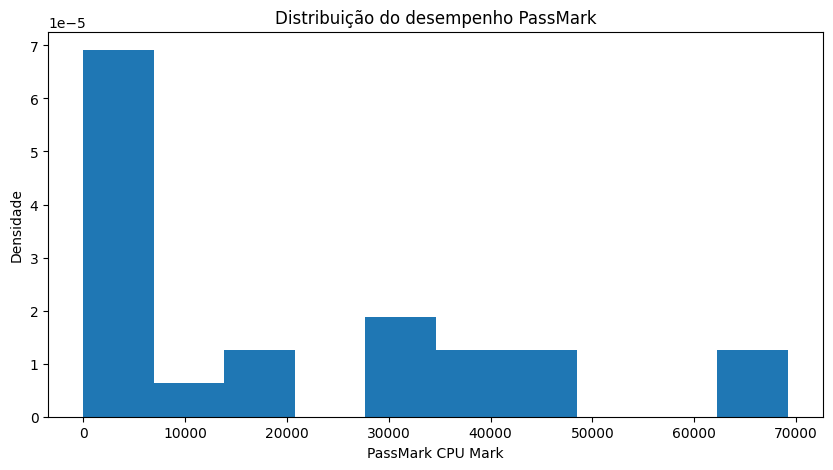

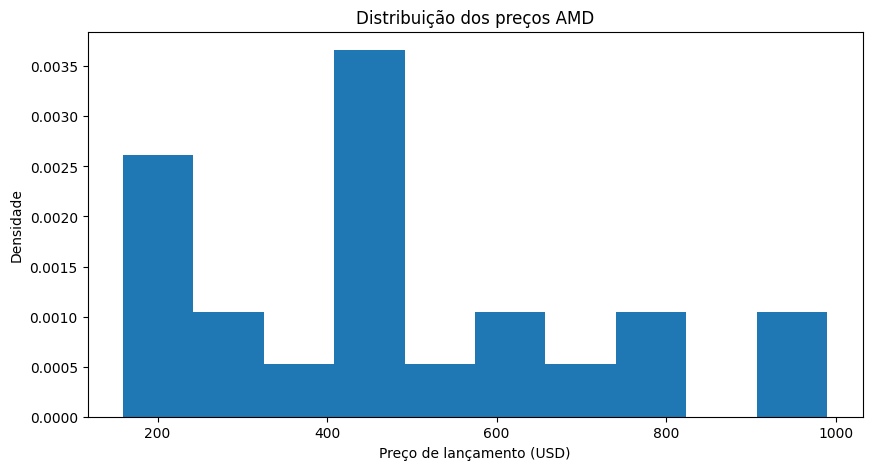

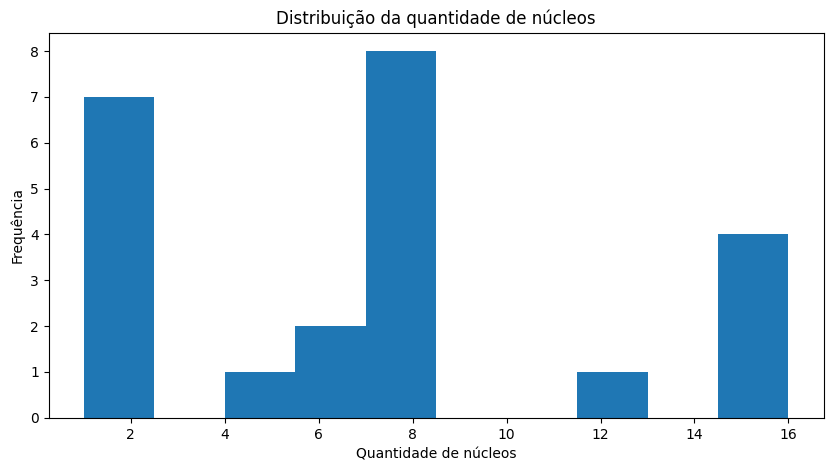

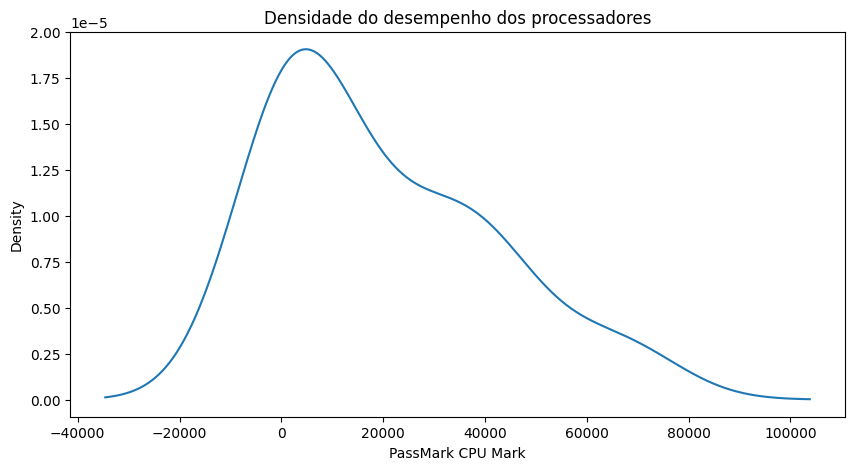

In [ ]:
# ==============================
# 4) DISTRIBUIÇÕES
# ==============================

from scipy.stats import skew, kurtosis

variaveis = [
    'passmark_cpu_mark',
    'launch_price_usd',
    'cores_total',
    'boost_clock_ghz'
]

for coluna in variaveis:
    dados = df[coluna].dropna()

    print(f"\nVariável: {coluna}")
    print("Assimetria:", skew(dados))
    print("Curtose:", kurtosis(dados))

# Histograma do desempenho
plt.figure(figsize=(10, 5))
plt.hist(df['passmark_cpu_mark'], bins=10, density=True)
plt.title('Distribuição do desempenho PassMark')
plt.xlabel('PassMark CPU Mark')
plt.ylabel('Densidade')
plt.show()

# Histograma dos preços
plt.figure(figsize=(10, 5))
plt.hist(df['launch_price_usd'], bins=10, density=True)
plt.title('Distribuição dos preços AMD')
plt.xlabel('Preço de lançamento (USD)')
plt.ylabel('Densidade')
plt.show()

# Histograma de núcleos
plt.figure(figsize=(10, 5))
plt.hist(df['cores_total'], bins=10)
plt.title('Distribuição da quantidade de núcleos')
plt.xlabel('Quantidade de núcleos')
plt.ylabel('Frequência')
plt.show()

# Densidade do desempenho
plt.figure(figsize=(10, 5))
df['passmark_cpu_mark'].plot(kind='density')
plt.title('Densidade do desempenho dos processadores')
plt.xlabel('PassMark CPU Mark')
plt.show()

# **Resposta das questões 4:**

**1. Como está distribuído o desempenho dos processadores?**

*Resposta:*

A distribuição do desempenho apresenta uma grande diferença entre os valores mínimos e máximos. O PassMark varia de 11 a 69.200 pontos, indicando a presença de processadores com capacidades de processamento bastante distintas. A média superior à mediana também sugere uma assimetria à direita, influenciada pelos modelos de maior desempenho.

**2. Como está distribuída a quantidade de núcleos?**

*Resposta:*

A quantidade de núcleos varia entre 1 e 16, com média de aproximadamente 7,17 e mediana de 8 núcleos. Isso demonstra que boa parte dos processadores analisados possui configurações próximas de 8 núcleos, embora existam modelos com quantidades menores e maiores.

**3. Como se comportam os preços dos processadores?**

*Resposta:*

Os preços variam entre US$ 159 e US$ 990, com mediana de US$ 449. Essa diferença demonstra que o conjunto contém processadores de diferentes faixas de preço, permitindo comparar modelos de entrada e modelos com valores mais elevados.

# 5. Relações entre Variáveis

**Métricas: covariância, correlação e tabelas cruzadas.**

**Perguntas adaptadas**

**Qual a correlação entre preço de lançamento e desempenho PassMark?**

**Processadores com mais núcleos também apresentam maior desempenho?**

**Existe relação entre consumo energético (TDP) e desempenho?**

**Código Python **

,launch_price_usd,passmark_cpu_mark,cores_total,threads_total,boost_clock_ghz,tdp_watts,ppt_watts,l3_cache_mb
launch_price_usd,1.00,0.38,0.43,0.42,0.28,0.40,0.41,0.26
passmark_cpu_mark,0.38,1.00,0.89,0.94,0.77,0.35,0.56,0.80
cores_total,0.43,0.89,1.00,0.98,0.84,0.45,0.63,0.66
threads_total,0.42,0.94,0.98,1.00,0.79,0.32,0.53,0.71
boost_clock_ghz,0.28,0.77,0.84,0.79,1.00,0.66,0.80,0.68
tdp_watts,0.40,0.35,0.45,0.32,0.66,1.00,0.97,0.29
ppt_watts,0.41,0.56,0.63,0.53,0.80,0.97,1.00,0.47
l3_cache_mb,0.26,0.80,0.66,0.71,0.68,0.29,0.47,1.00


,launch_price_usd,passmark_cpu_mark,cores_total,threads_total,boost_clock_ghz,tdp_watts,ppt_watts,l3_cache_mb
launch_price_usd,57367.58,1.982047e+06,538.35,1128.92,112.64,4656.04,6075.65,2145.15
passmark_cpu_mark,1982047.42,4.624808e+08,100032.28,225444.36,27539.90,371989.45,742353.38,600000.64
cores_total,538.35,1.000323e+05,27.15,56.94,7.28,114.68,204.39,118.89
threads_total,1128.92,2.254444e+05,56.94,125.51,14.75,178.16,368.19,277.11
boost_clock_ghz,112.64,2.753990e+04,7.28,14.75,2.76,53.44,82.44,38.98
tdp_watts,4656.04,3.719895e+05,114.68,178.16,53.44,2402.44,2940.66,497.18
ppt_watts,6075.65,7.423534e+05,204.39,368.19,82.44,2940.66,3857.68,1018.42
l3_cache_mb,2145.15,6.000006e+05,118.89,277.11,38.98,497.18,1018.42,1206.72


Correlação preço e desempenho: 0.3847989655356511
Correlação núcleos e desempenho: 0.892702623607602
Correlação TDP e desempenho: 0.35290496366247626


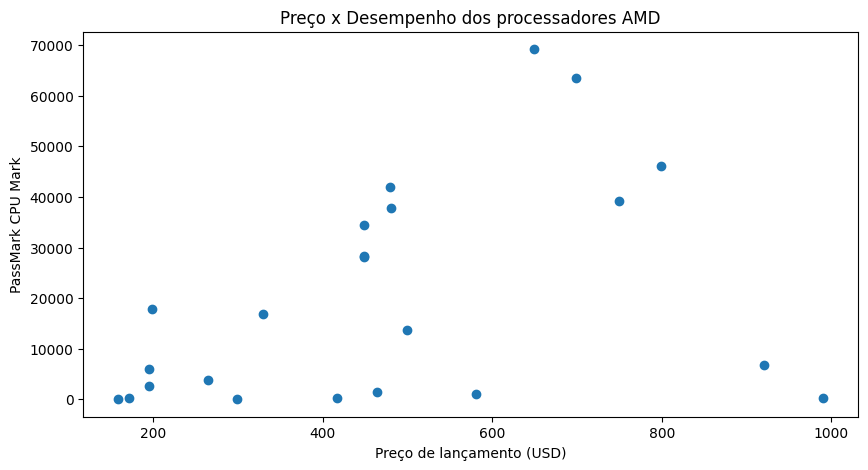

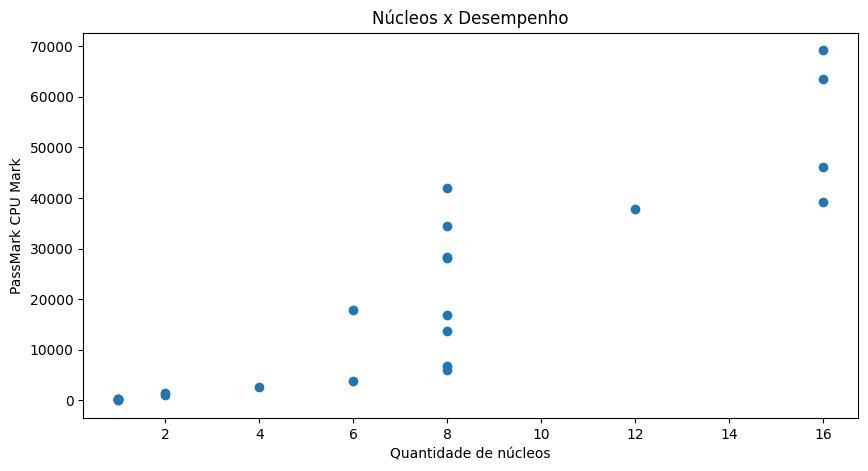

In [ ]:
# ==============================
# 5) RELAÇÕES ENTRE VARIÁVEIS
# ==============================

variaveis = [
    'launch_price_usd',
    'passmark_cpu_mark',
    'cores_total',
    'threads_total',
    'boost_clock_ghz',
    'tdp_watts',
    'ppt_watts',
    'l3_cache_mb'
]

# Matriz de correlação
correlacao = df[variaveis].corr()

display(correlacao.round(2)),


# Matriz de covariância
covariancia = df[variaveis].cov()

display(covariancia.round(2))

# Preço x desempenho
print(
    "Correlação preço e desempenho:",
    df['launch_price_usd'].corr(df['passmark_cpu_mark'])
)

# Núcleos x desempenho
print(
    "Correlação núcleos e desempenho:",
    df['cores_total'].corr(df['passmark_cpu_mark'])
)

# TDP x desempenho
print(
    "Correlação TDP e desempenho:",
    df['tdp_watts'].corr(df['passmark_cpu_mark'])
)

# Gráfico preço x desempenho
plt.figure(figsize=(10, 5))
plt.scatter(df['launch_price_usd'], df['passmark_cpu_mark'])
plt.title('Preço x Desempenho dos processadores AMD')
plt.xlabel('Preço de lançamento (USD)')
plt.ylabel('PassMark CPU Mark')
plt.show()

# Núcleos x desempenho
plt.figure(figsize=(10, 5))
plt.scatter(df['cores_total'], df['passmark_cpu_mark'])
plt.title('Núcleos x Desempenho')
plt.xlabel('Quantidade de núcleos')
plt.ylabel('PassMark CPU Mark')
plt.show()

# **Respostas das questões 5:**
**1. Existe relação entre preço e desempenho?**

*Resposta:*

A relação entre preço e desempenho pode ser analisada por meio da correlação e do gráfico de dispersão. Essa comparação permite verificar se processadores com preços mais elevados tendem a apresentar pontuações maiores no PassMark. Entretanto, o preço não deve ser considerado o único fator determinante do desempenho.

**2. Processadores com mais núcleos apresentam maior desempenho?**

*Resposta:*

A quantidade de núcleos é uma característica importante para o desempenho em tarefas que utilizam processamento paralelo. A comparação entre núcleos e PassMark permite investigar essa relação. Entretanto, outros fatores, como arquitetura, frequência e geração, também influenciam os resultados.

**3. Existe relação entre consumo energético e desempenho?**

*Resposta:*

O consumo energético pode apresentar relação com o desempenho, pois processadores com maior capacidade de processamento podem possuir limites de potência mais elevados. Entretanto, essa relação deve ser analisada considerando também a eficiência energética, que permite comparar o desempenho obtido por watt consumido.

# 6. Segmentações

**Grupos de análise: família, arquitetura e ano de lançamento.**

**Perguntas adaptadas**

**Quais famílias de processadores apresentam a maior média de desempenho?**

**Quais arquiteturas possuem maior eficiência energética?**

**Qual ano de lançamento apresenta a maior média de desempenho?**

,passmark_cpu_mark
family,
Ryzen 9,54500.000000
Ryzen AI,37800.000000
Ryzen 7,27266.666667
Ryzen 5,17850.000000
FX Series,6395.000000
Phenom II,3180.000000
Athlon 64 X2,1250.000000
Athlon 64,311.000000
Athlon XP,231.000000


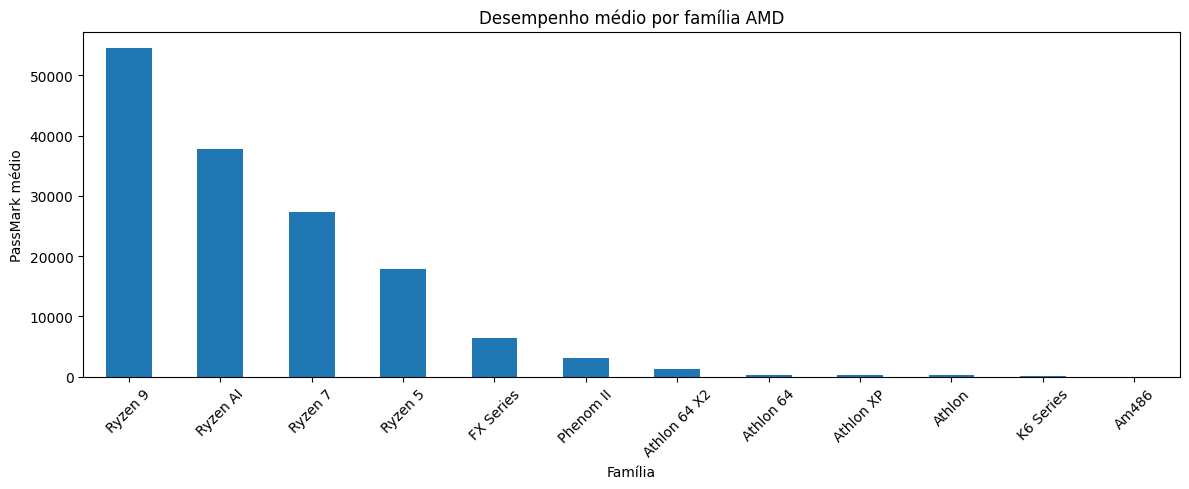

,passmark_per_watt
architecture,
Zen 5 + Zen 5c,1350.000
Zen 5,407.060
Zen 4,373.530
Zen 3,353.810
Zen 5 3D,350.000
Zen 2,323.975
Zen 4 3D,287.500
Zen 3 3D,270.480
Zen+,160.950


,passmark_cpu_mark
launch_year,
1994,11.000000
1998,60.000000
2000,210.000000
2003,271.000000
2005,1020.000000
2007,1480.000000
2009,2540.000000
2010,3820.000000
2012,5940.000000


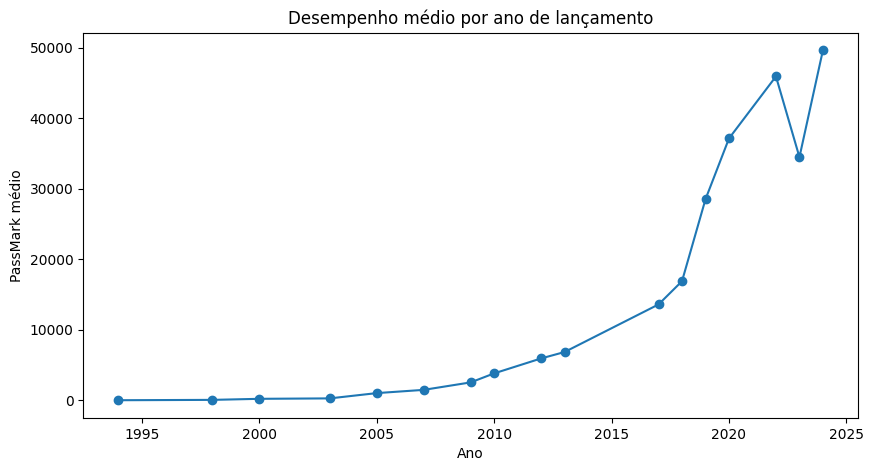

In [ ]:
# ==============================
# 6) SEGMENTAÇÕES
# ==============================

# Desempenho médio por família
desempenho_familia = df.groupby('family')[
    'passmark_cpu_mark'
].mean().sort_values(ascending=False)

display(desempenho_familia)

plt.figure(figsize=(12, 5))
desempenho_familia.plot(kind='bar')
plt.title('Desempenho médio por família AMD')
plt.xlabel('Família')
plt.ylabel('PassMark médio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Eficiência energética por arquitetura
eficiencia = df.groupby('architecture')[
    'passmark_per_watt'
].mean().sort_values(ascending=False)

display(eficiencia)

# Desempenho por ano
desempenho_ano = df.groupby('launch_year')[
    'passmark_cpu_mark'
].mean()

display(desempenho_ano)

plt.figure(figsize=(10, 5))
desempenho_ano.plot(kind='line', marker='o')
plt.title('Desempenho médio por ano de lançamento')
plt.xlabel('Ano')
plt.ylabel('PassMark médio')
plt.show()

# **Respostas das questões 6:**
**1. Como o desempenho varia entre as famílias de processadores AMD?**

*Resposta:*

A comparação entre as famílias permite observar diferenças no desempenho médio dos processadores. Essas diferenças podem estar relacionadas às gerações, arquiteturas e configurações de hardware. A análise do PassMark médio por família permite identificar como o desempenho está distribuído entre os grupos.

**2. Qual arquitetura apresenta maior eficiência energética?**

*Resposta:*

A eficiência energética pode ser comparada utilizando a variável passmark_per_watt. Essa métrica representa a relação entre desempenho e consumo de energia. A arquitetura com maior média nessa variável apresenta maior desempenho por watt dentro do conjunto analisado.

**3. Como o desempenho evoluiu ao longo dos anos?**

*Resposta:*

A análise por ano de lançamento permite observar a evolução do desempenho dos processadores AMD. A comparação das pontuações médias do PassMark ao longo dos anos possibilita identificar mudanças no desempenho entre diferentes períodos, que podem estar relacionadas aos avanços tecnológicos e às novas arquiteturas.

# 7. Outliers

**Métodos: boxplot, Z-score e IQR.**

**Perguntas adaptadas**

**Existem processadores com desempenho extremamente alto ou baixo?**

**O preço de algum processador destoa muito do desempenho apresentado?**

**Existem processadores com consumo energético fora do padrão?**

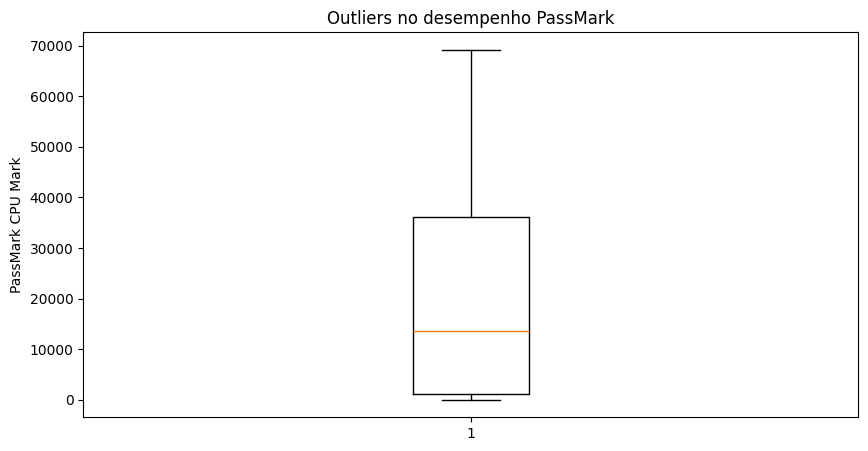

,processor_name,passmark_cpu_mark


,processor_name,passmark_cpu_mark,z_score
18,AMD Ryzen 9 7950X,63500.0,2.023311
21,AMD Ryzen 9 9950X,69200.0,2.288361


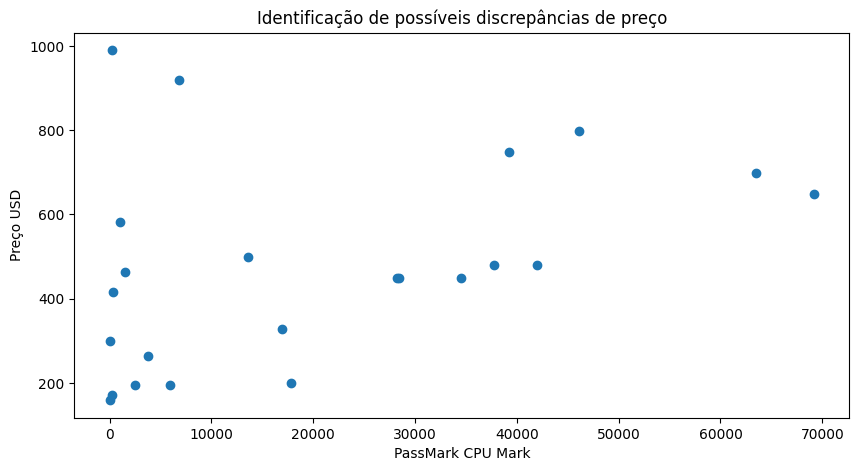

In [ ]:
# ==============================
# 7) OUTLIERS
# ==============================

import matplotlib.pyplot as plt

# Boxplot do desempenho
plt.figure(figsize=(10, 5))
plt.boxplot(df['passmark_cpu_mark'])
plt.title('Outliers no desempenho PassMark')
plt.ylabel('PassMark CPU Mark')
plt.show()

# Método IQR
Q1 = df['passmark_cpu_mark'].quantile(0.25)
Q3 = df['passmark_cpu_mark'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[
    (df['passmark_cpu_mark'] < limite_inferior) |
    (df['passmark_cpu_mark'] > limite_superior)
]

display(outliers[['processor_name', 'passmark_cpu_mark']])

# Z-score
df['z_score'] = (
    df['passmark_cpu_mark'] - df['passmark_cpu_mark'].mean()
) / df['passmark_cpu_mark'].std()

outliers_z = df[abs(df['z_score']) > 2]

display(outliers_z[['processor_name', 'passmark_cpu_mark', 'z_score']])

# Preço x desempenho
plt.figure(figsize=(10, 5))
plt.scatter(df['passmark_cpu_mark'], df['launch_price_usd'])
plt.title('Identificação de possíveis discrepâncias de preço')
plt.xlabel('PassMark CPU Mark')
plt.ylabel('Preço USD')
plt.show()

# **Respostas das questões 7:**
**1. Existem valores discrepantes no desempenho dos processadores?**

*Resposta:*

A identificação de valores discrepantes pode ser realizada utilizando o método do intervalo interquartil (IQR). Processadores que apresentam pontuações muito distantes da distribuição central podem ser classificados como outliers. Esses valores podem representar modelos com desempenho muito superior ou inferior aos demais.

**2. Existem preços muito diferentes dos demais processadores?**

*Resposta:*

A análise dos preços permite identificar modelos que apresentam valores significativamente acima ou abaixo da distribuição central. Esses casos devem ser observados para compreender se representam características específicas dos produtos ou diferenças entre as categorias de processadores.

**3. Os processadores com maior preço também apresentam maior desempenho?**

*Resposta:*

A comparação entre preço e PassMark permite investigar essa relação. Um processador com preço elevado não necessariamente apresenta a maior eficiência ou o melhor desempenho proporcional ao seu custo. Por isso, é importante analisar também a variável PassMark por dólar.

# **8. Visualização e Storytelling**

**Gráficos: boxplot, scatter e heatmap de correlação.**

**Perguntas adaptadas**

**Como o desempenho varia entre as famílias de processadores?**

**Qual relação entre as variáveis apresenta a maior correlação?**

**Qual família se destaca quando cruzamos desempenho e eficiência energética?**

<Figure size 1200x600 with 0 Axes>

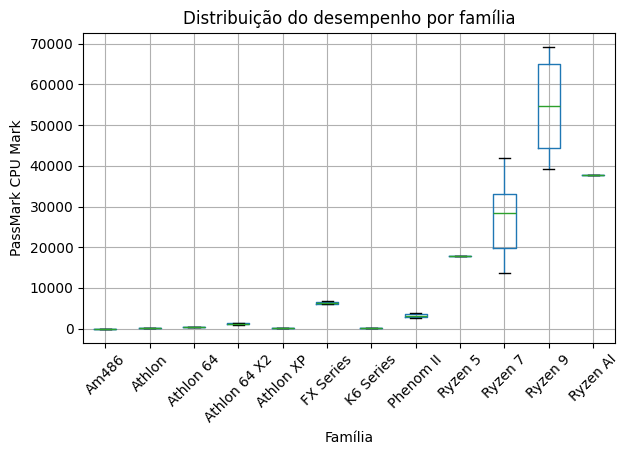

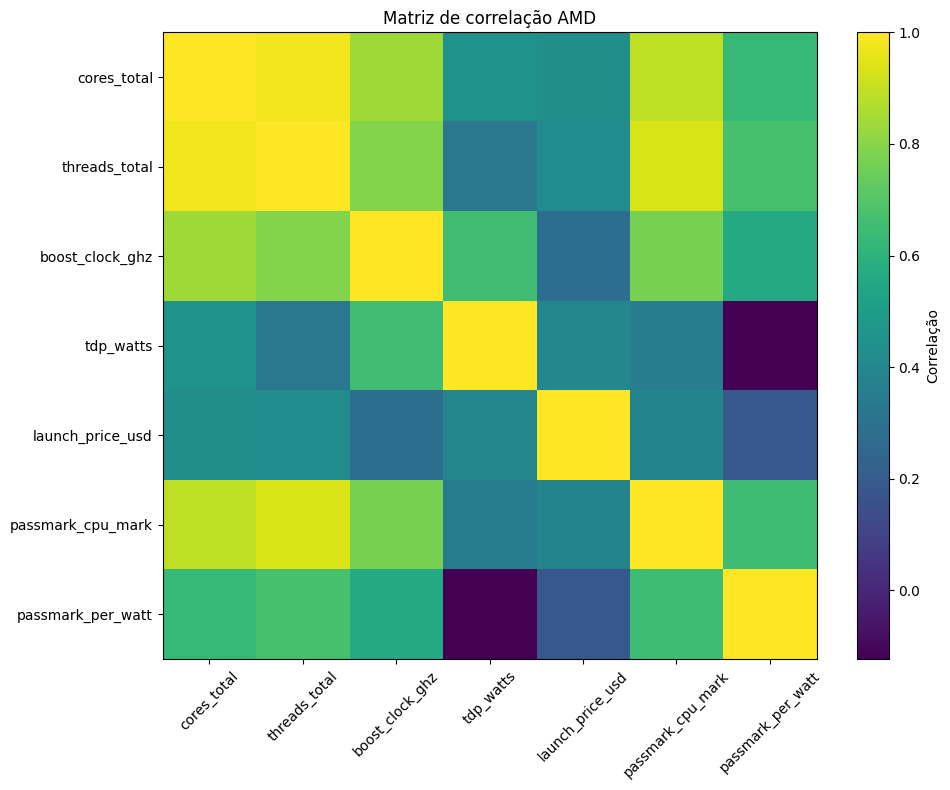

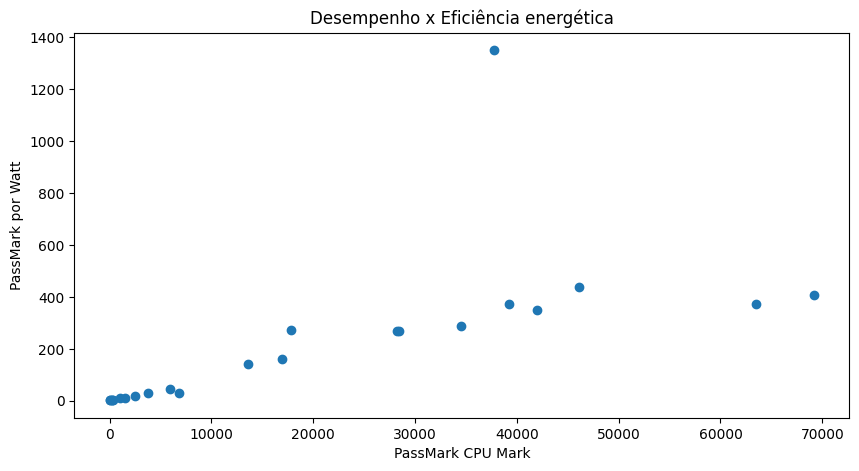

In [ ]:
# ==============================
# 8) VISUALIZAÇÃO E STORYTELLING
# ==============================

# Boxplot por família
plt.figure(figsize=(12, 6))

df.boxplot(
    column='passmark_cpu_mark',
    by='family'
)

plt.title('Distribuição do desempenho por família')
plt.suptitle('')
plt.xlabel('Família')
plt.ylabel('PassMark CPU Mark')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Heatmap de correlação
variaveis = [
    'cores_total',
    'threads_total',
    'boost_clock_ghz',
    'tdp_watts',
    'launch_price_usd',
    'passmark_cpu_mark',
    'passmark_per_watt'
]

corr = df[variaveis].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect='auto')
plt.colorbar(label='Correlação')

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Matriz de correlação AMD')
plt.tight_layout()
plt.show()

# Desempenho x eficiência
plt.figure(figsize=(10, 5))
plt.scatter(df['passmark_cpu_mark'], df['passmark_per_watt'])

plt.title('Desempenho x Eficiência energética')
plt.xlabel('PassMark CPU Mark')
plt.ylabel('PassMark por Watt')
plt.show()

# **Respostas das questões 8:**

**1. Como o desempenho varia entre as famílias de processadores?**

*Resposta:*

O gráfico de comparação entre famílias permite visualizar diferenças no desempenho dos processadores AMD. A utilização de medidas como média, mediana e dispersão ajuda a compreender tanto o desempenho típico quanto a variação existente dentro de cada família.

**2. Qual relação entre as variáveis apresenta a maior correlação?**

*Resposta:*

A matriz de correlação permite identificar quais variáveis apresentam relações lineares mais fortes. A análise deve considerar as correlações positivas e negativas, permitindo observar quais características estão mais associadas ao desempenho dos processadores.

**3. Qual família se destaca quando cruzamos desempenho e eficiência energética?**

*Resposta:*

A comparação entre desempenho e eficiência energética permite identificar famílias que apresentam pontuações elevadas no PassMark e bons resultados de desempenho por watt. Essa análise oferece uma visão mais completa do comportamento dos processadores, considerando tanto sua capacidade de processamento quanto o consumo energético.

# **9. Síntese e Interpretação**
# Relatório final

A análise exploratória do dataset de processadores AMD, composto por 23 registros, permite investigar a evolução tecnológica dos processadores considerando desempenho, consumo energético, preço, quantidade de núcleos e características de fabricação.

Os resultados descritivos indicam uma média de 19.987,96 pontos no PassMark CPU Mark, com desvio padrão de 21.505,37 pontos. O preço médio de lançamento é de US$ 473,30.

A análise de dispersão permite observar diferenças entre os modelos, enquanto a distribuição dos dados auxilia na identificação de concentrações e valores extremos.

As relações entre desempenho, preço, núcleos, frequência e consumo energético permitem investigar características associadas à capacidade de processamento e eficiência dos produtos.

A segmentação por família, arquitetura e ano de lançamento contribui para compreender as diferenças entre gerações e categorias de processadores.

Por fim, a análise de outliers e as visualizações estatísticas complementam a interpretação dos dados, proporcionando uma visão geral das características dos processadores AMD presentes na amostra.